# Trainer11 Meeting Feedback Summary

> 기준 모델: `/home/carol/chaeyeon-kim/alpha26/trainer11.ipynb`  
> 정리일: 2026-05-07  
> 목적: 현재 world model이 reconstruction을 못 하는 원인이 latent capacity 문제인지, 아니면 task 난이도/데이터 파이프라인/학습 설정 문제인지 단계적으로 확인한다.

## 교수님 피드백 핵심

- 현재 `h_t`, `z_t` 차원이 작아서 고해상도 reconstruction이 어려울 수 있다.
- 바로 latent size를 키우기보다, 먼저 모델이 풀기 쉬운 문제로 바꿔서 reconstruction 가능성을 확인한다.
- reconstruction target을 약 `1/8` 수준으로 줄이고, `h_t=128` 상태에서 local/server 실험을 먼저 돌린다.
- LiDAR 입력도 `64x512`에서 더 낮은 range-view 해상도로 줄여본다.
- 데이터 temporal resolution은 `10Hz`까지 필요 없고 `2Hz` 정도면 충분할 수 있다.
- epoch `200`은 너무 길 수 있으니 짧은 ablation으로 경향성을 먼저 본다.
- TensorBoard 등으로 loss graph를 남기고, learning rate부터 hyperparameter tuning을 한다.
- 병목이 생기는 부분을 먼저 찾아 해결한다.
- 정량 평가는 MUVO에서 쓰는 metric과 유사하게 비교한다.
- 이 모델을 기준 모델로 두고, “무엇을 바꿨더니 어떻게 변했는지”를 log/table로 남긴다.
- 데이터는 매번 전체를 들고 있는 방식보다, pkl manifest에 데이터 경로를 저장하고 dataloader에서 필요한 sample을 step마다 가져오는 방식이 일반적이다.
- sequence 구성은 하나의 기준 sample에서 이전/이후 sample을 불러오는 구조가 배치/sequence 변경에 더 안정적이다.

## 이번 노트북에 반영한 변경

- `cfg.DATA`를 추가해 데이터/해상도/sampling 설정을 한 곳에서 관리한다.
- RGB reconstruction target을 `608x800`에서 `216x288`로 줄였다.
  - pixel 수 기준 약 `12.8%`로, 교수님이 말씀하신 `1/8` 수준에 가깝다.
- LiDAR range view를 `64x512`에서 `32x256`으로 줄였다. `H=32`는 Immanuel dataset의 CARLA LiDAR `channels=32`에 맞춘 값이고, vertical projection은 CARLA/MUVO 공통 FOV `[-30, 10]` 기준으로 수정했다.
- 원본 저장 row가 simulation 기준 약 `4Hz`이므로 `SAMPLE_EVERY_N=2`를 적용해 약 `2Hz`로 사용한다.
- `h_t=128`, `z_t=64`는 유지해서 먼저 쉬운 reconstruction 문제를 풀 수 있는지 확인한다.
- `STEPS=6000`으로 줄여 local ablation을 빠르게 돌릴 수 있게 했다.
- Arrow 파일 경로를 모으는 pkl manifest를 추가했다.
  - 기본 경로: `/home/carol/chaeyeon-kim/processed/arrow_manifest.pkl`
- 단일 Arrow뿐 아니라 여러 Arrow 파일을 이어서 사용할 수 있도록 `MultiArrowStreamDataset`을 추가했다.
- decoder output size가 config를 따르도록 바꿔, target resolution을 바꿔도 loss target과 output shape이 맞도록 했다.
- TensorBoard logger 이름을 `trainer11_lowres_2hz`로 지정했다.
- 같은 설정을 바로 실행할 수 있는 script를 추가했다.
  - `/home/carol/chaeyeon-kim/alpha26/scripts/trainer11_lowres_2hz.py`
- 실험 비교용 CSV를 추가했고, 학습 종료 시 `experiment_log.csv`에 실험 설정과 final validation metric을 자동 append한다.
  - `/home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv`

## 현재 실험 설정

| 항목 | 값 |
|---|---:|
| receptive field | `4` |
| future horizon | `4` |
| sequence length | `8` |
| sampling | 약 `2Hz` (`SAMPLE_EVERY_N=2`) |
| RGB encoder input | `300x400` |
| RGB reconstruction target | `216x288` |
| LiDAR range view | `32x256` |
| LiDAR vertical FOV | `[-30, 10]` degrees |
| hidden state `h_t` | `128` |
| stochastic state `z_t` | `64` |
| learning rate | `1e-4` |
| max steps | `6000` |
| batch size | `2` |
| scheduler | `none` |

## 검증된 첫 sample shape

```text
image      (8, 3, 300, 400)
image_raw  (8, 3, 216, 288)
lidar      (8, 4, 32, 256)
action     (8, 2)
```

## 추천 실험 순서

1. `trainer11_lowres_2hz` 설정으로 짧게 학습해서 reconstruction이 되는지 먼저 확인한다.
2. TensorBoard에서 `train_loss`, `val/RL_*`, `val/DS_*`, future metric을 확인한다.
3. learning rate를 `3e-5`, `1e-4`, `3e-4` 정도로 비교한다.
4. 결과가 조금이라도 안정되면 한 번에 하나씩만 바꾼다.
   - `h_t/z_t` 증가
   - RGB target resolution 증가
   - LiDAR resolution 증가
   - train run 수 증가
5. 각 실험 결과를 `experiment_log.csv`에 한 줄씩 기록해서 table로 비교한다.


## LiDAR Range-View Projection Note

이번 수정의 핵심은 LiDAR 원본 데이터와 range-view target의 의미를 분리해서 정리하는 것이다.

- Immanuel Peter dataset은 CARLA `sensor.lidar.ray_cast` raw point cloud를 저장한다.
  - 수집 설정: `channels=32`, `range=80`, `rotation_frequency=20`, `points_per_second=200000`
  - 저장 형태: `Nx4 = x, y, z, intensity`
- 수집 script에서 `upper_fov`, `lower_fov`는 따로 override하지 않았다.
  - 따라서 CARLA 기본값인 `lower_fov=-30`, `upper_fov=10`을 사용한 것으로 본다.
- MUVO도 range projection에서 `POINTS.FOV = [-30, 10]`을 사용한다.
- 따라서 우리 range-view 변환도 pitch를 `[-90, 90]`처럼 정규화하면 안 되고, `[-30, 10]` vertical FOV 안에서 정규화해야 한다.

현재 설정의 의미:

| 항목 | 의미 | 현재 값 |
|---|---|---:|
| `C` | range-view feature channels | `4` (`x,y,z,range`) |
| `H` | vertical LiDAR channels / beams | `32` |
| `W` | horizontal azimuth raster bins | `256` |
| vertical FOV | CARLA ray-cast default and MUVO-compatible FOV | `[-30, 10]` |

`H=32`는 수집 LiDAR의 beam/channel 수에 맞춘 값이다. `W=256`은 raw point cloud에 원래 존재하는 고정 image width가 아니라, 360도 azimuth를 몇 개 bin으로 rasterize할지 정하는 실험 파라미터다. 원본 수집 설정에서 한 frame은 대략 `200000 / 20 = 10000` points이고, channel당 약 `312.5` points이므로 `W=256`은 가벼운 local ablation 값으로 둔다. 더 조밀하게 보려면 `W=320` 또는 `512`를 다음 실험으로 비교한다.


## Automatic Experiment CSV Logging

학습이 끝나면 `ExperimentCSVLogger` callback이 `/home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv`에 한 줄을 자동으로 추가한다.

자동 기록되는 항목:

- run name, train/validation Arrow 파일명
- sampling Hz, RGB reconstruction size, LiDAR range-view size, LiDAR FOV
- `h_t`, `z_t`, learning rate, max steps, scheduler, batch size
- 마지막 validation에서 남은 주요 metric
  - `val/RL_loss`, `val/DS_loss`
  - RGB PSNR
  - LiDAR Chamfer metric
  - future LiDAR Chamfer metric
- TensorBoard log directory

주의: 현재 값은 checkpoint selection 기준의 “best”가 아니라, `trainer.fit()` 종료 시점의 final validation metric이다. 이후 `ModelCheckpoint(monitor=...)`를 지정하면 best metric 기반 기록으로 확장할 수 있다.


In [1]:
import pyarrow as pa
import os
import bisect
import pickle
import glob
from datetime import date
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning.pytorch as pl
import timm
import numpy as np
from PIL import Image
import io
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import List, Optional
import math
from types import SimpleNamespace


In [2]:

#######################
# cfg
#######################
cfg = SimpleNamespace(
    RECEPTIVE_FIELD=4,
    FUTURE_HORIZON=4,

    DATA=SimpleNamespace(
        ROOT="/home/carol/chaeyeon-kim/processed",
        MANIFEST_PATH="/home/carol/chaeyeon-kim/processed/arrow_manifest.pkl",
        TRAIN_RUN="train_run_002.arrow",
        VAL_RL_RUN="validation_run_008.arrow",
        VAL_DS_RUN="validation_run_024.arrow",
        USE_ALL_TRAIN_RUNS=False,   # local ablation은 False로 빠르게, 서버 학습은 True로 확장
        IMAGE_INPUT_SIZE=(300, 400),
        RGB_RECON_SIZE=(216, 288),  # 608x800 대비 약 1/8 pixels 수준의 reconstruction target
        # Immanuel dataset uses CARLA ray_cast LiDAR with channels=32.
        # W is a rasterisation choice for azimuth bins; 256 keeps the local ablation light.
        LIDAR_RANGE_VIEW_SIZE=(32, 256),
        LIDAR_FOV_DEGREES=(-30.0, 10.0),  # CARLA ray_cast default lower/upper FOV, also used by MUVO
        SAMPLE_EVERY_N=2,           # 원본 저장 주기 4Hz에서 한 칸 건너뛰어 약 2Hz
        FRAME_STEP=5,               # CARLA 20Hz에서 SAVE_EVERY_N=5로 저장된 frame 간격
    ),

    MODEL=SimpleNamespace(
        ACTION_DIM=2,
        SPEED_CHANNELS=16,
        TRANSITION=SimpleNamespace(
            ENABLED=True,
            HIDDEN_STATE_DIM=128,
            STATE_DIM=64,
            ACTION_LATENT_DIM=32,
            USE_DROPOUT=False,
            DROPOUT_PROBABILITY=0.0,
        ),
    ),

    LOSSES=SimpleNamespace(
        WEIGHT_PROBABILISTIC=1e-3,
        KL_BALANCING_ALPHA=0.75,
        WEIGHT_LIDAR_RE=1.0,
        WEIGHT_LIDAR_EMPTY=0.05,
        WEIGHT_RGB=0.1,
        WEIGHT_FUTURE=1.0,
    ),

    OPTIMIZER=SimpleNamespace(
        LR=1e-4,
        WEIGHT_DECAY=0.01,
        ACCUMULATE_GRAD_BATCHES=1,
    ),

    SCHEDULER=SimpleNamespace(
        NAME='none',          # 'OneCycleLR' or 'none'
        PCT_START=0.3,
    ),

    LOGGING=SimpleNamespace(
        RUN_NAME="trainer11_lowres_2hz",
        EXPERIMENT_LOG_PATH="/home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv",
    ),

    STEPS=6000,  # local ablation: 짧게 돌려 경향 확인 후 늘리기
    PRETRAINED=SimpleNamespace(
        PATH=None,
    ),
)


In [3]:

#######################
# point cloud to range view / data manifest
#######################
def _make_img_transform_raw(size=None):
    size = size or cfg.DATA.RGB_RECON_SIZE
    return transforms.Compose([
        transforms.Resize(tuple(size)),
        transforms.ToTensor(),
    ])


def _make_img_transform(size=None):
    size = size or cfg.DATA.IMAGE_INPUT_SIZE
    return transforms.Compose([
        transforms.Resize(tuple(size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


img_transform_raw = _make_img_transform_raw()
img_transform = _make_img_transform()


def point_cloud_to_range_view(points, H=None, W=None, fov_degrees=None):
    if H is None or W is None:
        H, W = cfg.DATA.LIDAR_RANGE_VIEW_SIZE
    fov_down_deg, fov_up_deg = fov_degrees or cfg.DATA.LIDAR_FOV_DEGREES
    fov_down = np.deg2rad(fov_down_deg)
    fov_up = np.deg2rad(fov_up_deg)
    fov = fov_up - fov_down

    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    yaw   = np.arctan2(y, x)
    pitch = np.arcsin(z / (r + 1e-8))

    yaw_img = (yaw / np.pi + 1.0) / 2.0
    pitch_img = (pitch - fov_down) / fov
    valid = np.isfinite(r) & (r > 0) & (pitch_img >= 0.0) & (pitch_img <= 1.0)

    x, y, z, r = x[valid], y[valid], z[valid], r[valid]
    yaw_img = yaw_img[valid]
    pitch_img = pitch_img[valid]

    col = np.clip((yaw_img * (W - 1)).astype(int), 0, W - 1)
    row = np.clip(((1.0 - pitch_img) * (H - 1)).astype(int), 0, H - 1)

    order = np.argsort(r)[::-1]
    rv = np.zeros((4, H, W), dtype=np.float32)
    rv[0, row[order], col[order]] = x[order]
    rv[1, row[order], col[order]] = y[order]
    rv[2, row[order], col[order]] = z[order]
    rv[3, row[order], col[order]] = r[order]
    return rv


def build_arrow_manifest(root=None, out_path=None):
    root = root or cfg.DATA.ROOT
    out_path = out_path or cfg.DATA.MANIFEST_PATH
    files = sorted(glob.glob(os.path.join(root, "*.arrow")))
    manifest = {
        "root": root,
        "train": [p for p in files if os.path.basename(p).startswith("train_")],
        "validation": [p for p in files if os.path.basename(p).startswith("validation_")],
        "test": [p for p in files if os.path.basename(p).startswith("test_")],
    }
    with open(out_path, "wb") as f:
        pickle.dump(manifest, f)
    return manifest


def load_arrow_manifest(path=None, root=None, rebuild=False):
    path = path or cfg.DATA.MANIFEST_PATH
    if rebuild or not os.path.exists(path):
        return build_arrow_manifest(root=root, out_path=path)
    with open(path, "rb") as f:
        return pickle.load(f)


def _as_arrow_path(name_or_path):
    if os.path.isabs(name_or_path):
        return name_or_path
    return os.path.join(cfg.DATA.ROOT, name_or_path)


class MUVODataset(Dataset):
    def __init__(self, arrow_file, seq_len=4, stride=None, sample_every_n=None,
                 image_input_size=None, rgb_recon_size=None, lidar_size=None,
                 frame_step=None, require_contiguous_frames=True):
        self.seq_len = int(seq_len)
        self.sample_every_n = int(sample_every_n or cfg.DATA.SAMPLE_EVERY_N)
        self.stride = self.seq_len if stride is None else int(stride)
        self.arrow_file = _as_arrow_path(arrow_file)
        self.lidar_size = tuple(lidar_size or cfg.DATA.LIDAR_RANGE_VIEW_SIZE)
        self.img_transform = _make_img_transform(image_input_size or cfg.DATA.IMAGE_INPUT_SIZE)
        self.img_transform_raw = _make_img_transform_raw(rgb_recon_size or cfg.DATA.RGB_RECON_SIZE)
        self.frame_step = int(frame_step or cfg.DATA.FRAME_STEP)
        self.require_contiguous_frames = require_contiguous_frames

        self._mmap = pa.memory_map(self.arrow_file, "r")
        reader = pa.ipc.open_stream(self._mmap)
        self.table = reader.read_all()
        self.n = self.table.num_rows

        self.index = []
        run_ids = self.table.column("run_id").to_pylist()
        frames = self.table.column("frame").to_pylist() if "frame" in self.table.column_names else None
        max_offset = (self.seq_len - 1) * self.sample_every_n
        for i in range(0, self.n - max_offset, self.stride):
            offsets = [j * self.sample_every_n for j in range(self.seq_len)]
            if not all(run_ids[i + off] == run_ids[i] for off in offsets):
                continue
            if self.require_contiguous_frames and frames is not None:
                expected = self.frame_step * self.sample_every_n
                if not all(frames[i + offsets[j]] - frames[i + offsets[j - 1]] == expected
                           for j in range(1, self.seq_len)):
                    continue
            self.index.append(i)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        i = self.index[idx]
        images, images_raw, lidars, actions, speeds = [], [], [], [], []

        for j in range(self.seq_len):
            k = i + j * self.sample_every_n
            row = self.table.slice(k, 1)
            img_bytes = row.column("image_front")[0].as_py()["bytes"]
            img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
            images.append(self.img_transform(img))
            images_raw.append(self.img_transform_raw(img))

            lidar_np = np.array(row.column("lidar")[0].as_py())
            lidars.append(torch.tensor(point_cloud_to_range_view(lidar_np, *self.lidar_size)))

            actions.append([row.column("throttle")[0].as_py(), row.column("steer")[0].as_py()])
            speeds.append(row.column("speed_kmh")[0].as_py())

        return {
            "image":     torch.stack(images),
            "image_raw": torch.stack(images_raw),
            "lidar":  torch.stack(lidars),
            "action": torch.tensor(actions),
            "speed":  torch.tensor(speeds),
            "run_id": self.table.column("run_id")[i].as_py(),
        }


class StreamWindowDataset(MUVODataset):
    """Interleave contiguous window streams so TBPTT hidden states stay aligned per batch position."""
    def __init__(self, arrow_file, seq_len=4, num_streams=1, stride=None, **kwargs):
        super().__init__(arrow_file, seq_len=seq_len, stride=stride, **kwargs)
        self.num_streams = max(1, int(num_streams))
        self.index = self._make_stream_order(self.index, self.num_streams)

    @staticmethod
    def _make_stream_order(index, num_streams):
        if num_streams <= 1 or len(index) == 0:
            return index

        chunk_size = math.ceil(len(index) / num_streams)
        chunks = [
            index[i * chunk_size: min((i + 1) * chunk_size, len(index))]
            for i in range(num_streams)
        ]
        chunks = [chunk for chunk in chunks if chunk]
        min_len = min(len(chunk) for chunk in chunks)

        ordered = []
        for t in range(min_len):
            for chunk in chunks:
                ordered.append(chunk[t])
        return ordered


class MultiArrowStreamDataset(Dataset):
    def __init__(self, arrow_files, seq_len=4, num_streams=1, stride=None, **kwargs):
        self.datasets = [
            StreamWindowDataset(path, seq_len=seq_len, num_streams=num_streams, stride=stride, **kwargs)
            for path in arrow_files
        ]
        self.datasets = [ds for ds in self.datasets if len(ds) > 0]
        if not self.datasets:
            raise ValueError("No non-empty Arrow datasets were found.")
        lengths = [len(ds) for ds in self.datasets]
        self.cumulative_lengths = np.cumsum(lengths).tolist()

    def __len__(self):
        return self.cumulative_lengths[-1]

    def __getitem__(self, idx):
        ds_idx = bisect.bisect_right(self.cumulative_lengths, idx)
        prev = 0 if ds_idx == 0 else self.cumulative_lengths[ds_idx - 1]
        return self.datasets[ds_idx][idx - prev]


In [4]:
#######################
# Image Encoder
#######################
class FPNDecoder(nn.Module):
    def __init__(self, feature_info, out_channels=128):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(feature_info[2], out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )
        self.skip_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(feature_info[i], out_channels, 3, 1, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(True),
            )
            for i in [1, 0]
        ])
        self.out_channels = out_channels

    def forward(self, xs: List[torch.Tensor]) -> torch.Tensor:
        x = self.conv1(xs[2])

        for i, conv in enumerate(self.skip_convs):
            size = xs[1 - i].shape[-2:]
            x = conv(xs[1 - i]) + F.interpolate(x, size=size, mode='bilinear', align_corners=False)

        return x

In [5]:
#######################
# Transformer Fusion
#######################
## num_pos_feats = C // 2
class PositionEmbeddingSine(nn.Module):
    def __init__(self, num_pos_feats=64, temperature=10000, normalize=False, scale=None):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature
        self.normalize = normalize
        if scale is not None and normalize is False:
            raise ValueError("normalize should be True if scale is passed")
        if scale is None:
            scale = 2 * math.pi
        self.scale = scale
    # 입력 feature의 크기(H,W)에 맞는 위치 embedding을 계산하는 함수 
    
    def forward(self, tensor):
        x = tensor
        B, C, h, w = x.shape

        not_mask = torch.ones((B, h, w), device=x.device)
        y_embed = not_mask.cumsum(1, dtype=torch.float32)
        x_embed = not_mask.cumsum(2, dtype=torch.float32)

        if self.normalize:
            eps = 1e-6
            y_embed = y_embed / (y_embed[:, -1:, :] + eps) * self.scale
            x_embed = x_embed / (x_embed[:, :, -1:] + eps) * self.scale

        dim_t = torch.arange(self.num_pos_feats, dtype=torch.float32, device=x.device)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_x = x_embed[:, :, :, None] / dim_t   # (B, h, w, num_pos_feats)
        pos_y = y_embed[:, :, :, None] / dim_t

        pos_x = torch.stack(
            (pos_x[:, :, :, 0::2].sin(), pos_x[:, :, :, 1::2].cos()), dim=4
        ).flatten(3)

        pos_y = torch.stack(
            (pos_y[:, :, :, 0::2].sin(), pos_y[:, :, :, 1::2].cos()), dim=4
        ).flatten(3)

        pos = torch.cat((pos_y, pos_x), dim=3).permute(0, 3, 1, 2)  # (B, C, h, w)
        return pos


class SensorFusionTransformer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels

        self.position_encode = PositionEmbeddingSine(
            num_pos_feats=channels // 2,
            normalize=True
        )

        # sensor type embedding: 0=camera, 1=lidar
        self.type_embedding = nn.Parameter(torch.zeros(2, channels))

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=8,
            dropout=0.1,
            batch_first=False   # default
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=6)

    def feature_to_tokens(self, x):
        # x: (B, C, H, W)
        # return: (H*W, B, C)
        return x.flatten(2).permute(2, 0, 1)

    def add_pos_and_type(self, x, sensor_type_idx):
        tokens = self.feature_to_tokens(x)          # (H*W, B, C)
        pos = self.position_encode(x)               # (B, C, H, W)
        pos_tokens = self.feature_to_tokens(pos)    # (H*W, B, C)
        NHW, B, C = tokens.shape
        type_embed = self.type_embedding[sensor_type_idx].view(1, 1, C).expand(NHW, B, C)
        tokens = tokens + pos_tokens + type_embed
        return tokens

    def forward(self, cam_feat, lidar_feat):
        # cam_feat:   (B, C, Hc, Wc)
        # lidar_feat: (B, C, Hl, Wl)
        # returns:    cam_out (B, C, Hc, Wc), lidar_out (B, C, Hl, Wl)
        B, C, Hc, Wc = cam_feat.shape
        _, _, Hl, Wl = lidar_feat.shape
        L_cam = Hc * Wc

        cam_tokens   = self.add_pos_and_type(cam_feat,   sensor_type_idx=0)  # (L_cam,   B, C)
        lidar_tokens = self.add_pos_and_type(lidar_feat, sensor_type_idx=1)  # (L_lidar, B, C)

        fused_tokens = torch.cat([cam_tokens, lidar_tokens], dim=0)  # (L_cam+L_lidar, B, C)
        out = self.transformer_encoder(fused_tokens)

        # 모달리티별 분리 후 공간 구조 복원
        cam_out   = out[:L_cam].permute(1, 2, 0).reshape(B, C, Hc, Wc)
        lidar_out = out[L_cam:].permute(1, 2, 0).reshape(B, C, Hl, Wl)
        return cam_out, lidar_out

In [6]:
#######################
# RSSM
#######################
class RepresentationModel(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.min_std = 0.1

        self.module = nn.Sequential(
            nn.Linear(in_channels, in_channels),
            nn.LeakyReLU(True),
            nn.Linear(in_channels, 2 * self.latent_dim),
        )

    def forward(self, x):
        def sigmoid2(tensor: torch.Tensor, min_value: float) -> torch.Tensor:
            return 2 * torch.sigmoid(tensor / 2) + min_value

        mu_log_sigma = self.module(x)
        mu, log_sigma = torch.split(mu_log_sigma, self.latent_dim, dim=-1)
        sigma = sigmoid2(log_sigma, self.min_std)
        return mu, sigma


class RSSM(nn.Module):
    def __init__(self, embedding_dim, action_dim, hidden_state_dim, state_dim,
                 action_latent_dim, receptive_field, use_dropout=False, dropout_probability=0.0):
        super().__init__()
        self.embedding_dim     = embedding_dim
        self.state_dim         = state_dim
        self.action_dim        = action_dim
        self.hidden_state_dim  = hidden_state_dim
        self.action_latent_dim = action_latent_dim
        self.receptive_field   = receptive_field
        self.use_dropout       = use_dropout
        self.dropout_probability = dropout_probability
        self.active_inference  = False

        # action을 GRU 입력에 명시적으로 포함: sample_t + latent_action_t → GRU
        self.pre_gru_net = nn.Sequential(
            nn.Linear(state_dim + action_latent_dim, hidden_state_dim),
            nn.LeakyReLU(True),
        )
        self.recurrent_model = nn.GRUCell(input_size=hidden_state_dim, hidden_size=hidden_state_dim)
        self.posterior_action_module = nn.Sequential(
            nn.Linear(action_dim, action_latent_dim), nn.LeakyReLU(True),
        )
        self.posterior = RepresentationModel(
            in_channels=hidden_state_dim + embedding_dim + action_latent_dim,
            latent_dim=state_dim,
        )
        self.prior_action_module = nn.Sequential(
            nn.Linear(action_dim, action_latent_dim), nn.LeakyReLU(True),
        )
        self.prior = RepresentationModel(
            in_channels=hidden_state_dim + action_latent_dim,
            latent_dim=state_dim,
        )

    def forward(self, input_embedding, action, h_init=None, s_init=None,
                use_sample=True, policy=None, continuation=False):
        """
        continuation=False: 시퀀스 시작 — t=0에서 이전 action 없으므로 zero 사용
        continuation=True:  이전 상태에서 이어지는 future 시퀀스 — action[:, t] 직접 사용
        """
        output = {"prior": [], "posterior": []}
        batch_size, sequence_length, _ = input_embedding.shape

        h_t = h_init if h_init is not None else input_embedding.new_zeros((batch_size, self.hidden_state_dim))
        sample_t = s_init if s_init is not None else input_embedding.new_zeros((batch_size, self.state_dim))

        for t in range(sequence_length):
            if continuation:
                action_t = action[:, t]
            else:
                action_t = torch.zeros_like(action[:, 0]) if t == 0 else action[:, t - 1]

            output_t = self.observe_step(h_t, sample_t, action_t, input_embedding[:, t],
                                         use_sample=use_sample, policy=policy)
            use_prior = (self.training and self.use_dropout
                         and torch.rand(1).item() < self.dropout_probability and t > 0)
            sample_t = output_t["prior"]["sample"] if use_prior else output_t["posterior"]["sample"]
            h_t = output_t["prior"]["hidden_state"]
            for key, value in output_t.items():
                output[key].append(value)

        return self.stack_list_of_dict_tensor(output, dim=1)

    def observe_step(self, h_t, sample_t, action_t, embedding_t, use_sample=True, policy=None):
        imagine_output = self.imagine_step(h_t, sample_t, action_t, use_sample, policy=policy)
        latent_action_t = self.posterior_action_module(action_t)
        posterior_mu_t, posterior_sigma_t = self.posterior(
            torch.cat([imagine_output["hidden_state"], embedding_t, latent_action_t], dim=-1)
        )
        sample_t = self.sample_from_distribution(posterior_mu_t, posterior_sigma_t, use_sample)
        return {
            "prior": imagine_output,
            "posterior": {
                "hidden_state": imagine_output["hidden_state"],
                "sample": sample_t,
                "mu": posterior_mu_t,
                "sigma": posterior_sigma_t,
            },
        }

    def imagine_step(self, h_t, sample_t, action_t, use_sample=True, policy=None):
        if self.active_inference:
            action_t = policy(torch.cat([h_t, sample_t], dim=-1))

        latent_action_t = self.prior_action_module(action_t)

        # action을 GRU 입력에 명시적으로 포함
        gru_input = torch.cat([sample_t, latent_action_t], dim=-1)
        input_t = self.pre_gru_net(gru_input)
        h_t = self.recurrent_model(input_t, h_t)

        prior_mu_t, prior_sigma_t = self.prior(torch.cat([h_t, latent_action_t], dim=-1))
        sample_t = self.sample_from_distribution(prior_mu_t, prior_sigma_t, use_sample)
        return {"hidden_state": h_t, "sample": sample_t, "mu": prior_mu_t, "sigma": prior_sigma_t}

    @staticmethod
    def sample_from_distribution(mu, sigma, use_sample):
        return mu + sigma * torch.randn_like(mu) if use_sample else mu

    @staticmethod
    def stack_list_of_dict_tensor(output, dim=1):
        new_output = {}
        for outer_key, outer_value in output.items():
            if outer_value:
                new_output[outer_key] = {
                    inner_key: torch.stack([x[inner_key] for x in outer_value], dim=dim)
                    for inner_key in outer_value[0].keys()
                }
        return new_output

In [7]:

#######################
# Decoder
#######################
class SensorHead(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_factor, sensor_type, output_size=None):
        super().__init__()
        self.downsample_factor = downsample_factor
        self.sensor_type = sensor_type
        self.output_size = tuple(output_size) if output_size is not None else None
        self.head = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x, B, S):
        out = self.head(x)
        if self.output_size is not None and out.shape[-2:] != self.output_size:
            out = F.interpolate(out, size=self.output_size, mode="bilinear", align_corners=False)
        _, C, H, W = out.shape
        return {
            f'{self.sensor_type}_{self.downsample_factor}': out.view(B, S, C, H, W)
        }


def _decoder_base_size(target_size):
    h, w = target_size
    return (max(1, math.ceil(h / 32)), max(1, math.ceil(w / 32)))


def _scaled_hw(target_size, scale):
    return (max(1, int(round(target_size[0] * scale))),
            max(1, int(round(target_size[1] * scale))))


class SensorDecoder(nn.Module):
    """
    Latent-only decoder, matching MUVO's world-model style.
    The final reconstruction size is configurable so local ablations can start
    from an easier low-resolution target before increasing h_t / z_t capacity.
    """
    def __init__(self, latent_n_channels, out_channels, target_size, sensor_type):
        super().__init__()

        self.target_size = tuple(target_size)
        constant_size = _decoder_base_size(self.target_size)

        self.linear = nn.Sequential(
            nn.Linear(latent_n_channels, 256),
            nn.Unflatten(-1, (256, 1, 1)),
        )

        self.base_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=constant_size),
            nn.ELU(),
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )
        self.head_4 = SensorHead(
            128, out_channels, downsample_factor=4, sensor_type=sensor_type,
            output_size=_scaled_hw(self.target_size, 0.5),
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )
        self.head_2 = SensorHead(
            64, out_channels, downsample_factor=2, sensor_type=sensor_type,
            output_size=self.target_size,
        )

    def forward(self, hidden_state, sample):
        B, S, _ = hidden_state.shape
        x = torch.cat([hidden_state, sample], dim=-1).reshape(B * S, -1)

        x = self.linear(x)
        x = self.base_conv(x)

        x = self.up1(x)
        out_4 = self.head_4(x, B, S)

        x = self.up2(x)
        out_2 = self.head_2(x, B, S)

        return {**out_4, **out_2}


In [8]:
#######################
# Model
#######################
class Model(nn.Module):
    def __init__(self, cfg, embedding_n_channels=128, transformer_encoder=None):
        super().__init__()
        self.cfg = cfg
        self.embedding_n_channels = embedding_n_channels
        self.receptive_field = self.cfg.RECEPTIVE_FIELD

        self.image_encoder = timm.create_model("resnet18", pretrained=True,
                                               features_only=True, out_indices=[2, 3, 4])
        self.image_fpn = FPNDecoder([128, 256, 512], out_channels=embedding_n_channels)

        self.lidar_encoder = timm.create_model("resnet18", pretrained=True,
                                               features_only=True, out_indices=[2, 3, 4], in_chans=4)
        self.lidar_fpn = FPNDecoder([128, 256, 512], out_channels=embedding_n_channels)

        self.transformer_encoder = (transformer_encoder if transformer_encoder is not None
                                    else SensorFusionTransformer(channels=embedding_n_channels))

        self.image_feature_compress = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(start_dim=1),
        )
        self.lidar_feature_compress = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(start_dim=1),
        )

        speed_channels = getattr(self.cfg.MODEL, "SPEED_CHANNELS", 16)
        self.speed_normalisation = 50.0  # speed_kmh normalisation
        self.speed_encoder = nn.Sequential(
            nn.Linear(1, speed_channels),
            nn.ReLU(True),
            nn.Linear(speed_channels, speed_channels),
            nn.ReLU(True),
        )
        self.features_combine = nn.Linear(2 * embedding_n_channels + speed_channels, embedding_n_channels)

        latent_dim = (self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM +
                      self.cfg.MODEL.TRANSITION.STATE_DIM)

        self.image_decoder = SensorDecoder(
            latent_n_channels=latent_dim,
            out_channels=3,
            target_size=tuple(self.cfg.DATA.RGB_RECON_SIZE),
            sensor_type='rgb',
        )
        self.lidar_decoder = SensorDecoder(
            latent_n_channels=latent_dim,
            out_channels=4,
            target_size=tuple(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE),
            sensor_type='lidar_reconstruction',
        )

        if not self.cfg.MODEL.TRANSITION.ENABLED:
            raise ValueError("cfg.MODEL.TRANSITION.ENABLED must be True.")

        self.rssm = RSSM(
            embedding_dim=embedding_n_channels,
            action_dim=self.cfg.MODEL.ACTION_DIM,
            hidden_state_dim=self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM,
            state_dim=self.cfg.MODEL.TRANSITION.STATE_DIM,
            action_latent_dim=self.cfg.MODEL.TRANSITION.ACTION_LATENT_DIM,
            receptive_field=self.receptive_field,
            use_dropout=self.cfg.MODEL.TRANSITION.USE_DROPOUT,
            dropout_probability=self.cfg.MODEL.TRANSITION.DROPOUT_PROBABILITY,
        )

    def encode_fuse_sequence(self, image, lidar, speed=None):
        B, S, C_img, H_img, W_img = image.shape
        _, _, C_lidar, H_lidar, W_lidar = lidar.shape

        image_flat = image.reshape(B * S, C_img, H_img, W_img)
        lidar_flat = lidar.reshape(B * S, C_lidar, H_lidar, W_lidar)

        cam_feat   = self.image_fpn(self.image_encoder(image_flat))
        lidar_feat = self.lidar_fpn(self.lidar_encoder(lidar_flat))

        _, C, _, _ = cam_feat.shape
        cam_feat   = F.adaptive_avg_pool2d(cam_feat,   (15, 20))
        lidar_feat = F.adaptive_avg_pool2d(lidar_feat, (8,  16))

        cam_out, lidar_out = self.transformer_encoder(cam_feat, lidar_feat)
        cam_emb   = self.image_feature_compress(cam_out).reshape(B, S, -1)
        lidar_emb = self.lidar_feature_compress(lidar_out).reshape(B, S, -1)

        if speed is None:
            speed = image.new_zeros(B, S)
        speed = speed.float().to(image.device)
        if speed.ndim == 2:
            speed = speed.unsqueeze(-1)
        speed_emb = self.speed_encoder(speed.reshape(B * S, 1) / self.speed_normalisation).reshape(B, S, -1)

        embedding = self.features_combine(torch.cat([cam_emb, lidar_emb, speed_emb], dim=-1))
        return embedding

    def forward(self, batch, h_init=None, s_init=None, deployment=False, continuation=False):
        image  = batch["image"].float()
        lidar  = batch["lidar"].float()
        speed  = batch.get("speed", None)

        if "action" in batch:
            action = batch["action"].float()
        elif "throttle_brake" in batch and "steering" in batch:
            action = torch.cat([batch["throttle_brake"], batch["steering"]], dim=-1).float()
        else:
            raise KeyError("batch must contain 'action' or both 'throttle_brake' and 'steering'.")

        embedding_seq = self.encode_fuse_sequence(image, lidar, speed=speed)

        rssm_output = self.rssm(
            input_embedding=embedding_seq,
            action=action,
            h_init=h_init,
            s_init=s_init,
            use_sample=True,
            policy=None,
            continuation=continuation,
        )

        output = {"prior": rssm_output["prior"], "posterior": rssm_output["posterior"]}

        ht = rssm_output["posterior"]["hidden_state"]
        st = rssm_output["posterior"]["sample"]

        if hasattr(self, "image_decoder"):
            output.update(self.image_decoder(ht, st))

        if hasattr(self, "lidar_decoder"):
            output.update(self.lidar_decoder(ht, st))

        return output, rssm_output

    def imagine(self, state_imagine, future_horizon=None):
        """
        Roll out future states with the prior only, then decode from latent state.
        """
        h_t      = state_imagine["hidden_state"]
        sample_t = state_imagine["sample"]
        device   = h_t.device

        if "action" in state_imagine:
            action = state_imagine["action"].float().to(device)
        elif "throttle_brake" in state_imagine and "steering" in state_imagine:
            action = torch.cat([
                state_imagine["throttle_brake"].float().to(device),
                state_imagine["steering"].float().to(device),
            ], dim=-1)
        else:
            raise KeyError("state_imagine must contain 'action' or both 'throttle_brake' and 'steering'.")

        if future_horizon is None:
            future_horizon = action.shape[1]
        future_horizon = min(future_horizon, action.shape[1])

        priors = {"hidden_state": [], "sample": [], "mu": [], "sigma": []}

        for t in range(future_horizon):
            prior_t = self.rssm.imagine_step(
                h_t=h_t, sample_t=sample_t, action_t=action[:, t],
                use_sample=True, policy=None,
            )
            h_t      = prior_t["hidden_state"]
            sample_t = prior_t["sample"]
            for key in priors:
                priors[key].append(prior_t[key])

        prior_seq = {k: torch.stack(v, dim=1) for k, v in priors.items()}

        output = {"prior": prior_seq}
        ht = prior_seq["hidden_state"]
        st = prior_seq["sample"]

        if hasattr(self, "image_decoder"):
            output.update(self.image_decoder(ht, st))

        if hasattr(self, "lidar_decoder"):
            output.update(self.lidar_decoder(ht, st))

        return output, {"prior": prior_seq}


In [9]:
#######################
# Training
#######################
class WorldModelTrainer(pl.LightningModule):

    def __init__(self, cfg=None, hparams=None, lr=None, embedding_n_channels=128):
        super().__init__()
        self.save_hyperparameters(ignore=["hparams"])

        self.cfg = cfg or hparams
        self.rf = self.cfg.RECEPTIVE_FIELD
        self.fh = self.cfg.FUTURE_HORIZON

        self.model = Model(self.cfg, embedding_n_channels=embedding_n_channels)
        self.load_pretrained_weights()

        self.lr = lr if lr is not None else getattr(self.cfg.OPTIMIZER, "LR", 1e-4)
        self.weight_probabilistic = getattr(self.cfg.LOSSES, "WEIGHT_PROBABILISTIC", 1e-3)
        self.kl_balancing_alpha   = getattr(self.cfg.LOSSES, "KL_BALANCING_ALPHA", 0.75)
        self.weight_lidar_re      = getattr(self.cfg.LOSSES, "WEIGHT_LIDAR_RE", 1.0)
        self.weight_lidar_empty   = getattr(self.cfg.LOSSES, "WEIGHT_LIDAR_EMPTY", 0.05)
        self.weight_rgb           = getattr(self.cfg.LOSSES, "WEIGHT_RGB", 0.1)
        self.weight_future        = getattr(self.cfg.LOSSES, "WEIGHT_FUTURE", 1.0)

        self._tbptt_h: Optional[torch.Tensor] = None
        self._tbptt_s: Optional[torch.Tensor] = None
        self._prev_run_id = None

        self.val_dataset_names = ["RL", "DS"]
        self.test_dataset_names = ["RL", "DS"]
        self.metric_max_chamfer_points = 2048

    # checkpoint
    def load_pretrained_weights(self):
        if not hasattr(self.cfg, "PRETRAINED"):
            return
        pretrained_path = getattr(self.cfg.PRETRAINED, "PATH", None)
        if not pretrained_path or not os.path.isfile(pretrained_path):
            return
        checkpoint = torch.load(pretrained_path, map_location="cpu")
        if "state_dict" in checkpoint:
            checkpoint = checkpoint["state_dict"]
        cleaned = {(k[len("model."):] if k.startswith("model.") else k): v
                   for k, v in checkpoint.items()}
        missing, unexpected = self.model.load_state_dict(cleaned, strict=False)
        print(f"Loaded: {pretrained_path}  missing={len(missing)}  unexpected={len(unexpected)}")

    # batch adapter
    def prepare_custom_batch(self, batch):
        if "action" in batch:
            if "throttle_brake" not in batch:
                batch["throttle_brake"] = batch["action"][..., 0:1]
            if "steering" not in batch:
                batch["steering"] = batch["action"][..., 1:2]
        if "range_view_pcd_xyzd" in batch and "lidar" not in batch:
            batch["lidar"] = batch["range_view_pcd_xyzd"].float()
        if "lidar" in batch and "range_view_label_1" not in batch:
            batch["range_view_label_1"] = batch["lidar"].float()
        if "image_raw" in batch and "rgb_label_1" not in batch:
            batch["rgb_label_1"] = batch["image_raw"].float()
        elif "image" in batch and "rgb_label_1" not in batch:
            batch["rgb_label_1"] = batch["image"].float()
        for key in ["image", "image_raw", "lidar", "action", "speed", "range_view_label_1", "rgb_label_1"]:
            if key in batch and torch.is_tensor(batch[key]):
                batch[key] = batch[key].float()
        return batch

    @staticmethod
    def _slice_batch(batch, start, end):
        sliced = {}
        for key, value in batch.items():
            if torch.is_tensor(value) and value.ndim >= 2:
                sliced[key] = value[:, start:end]
            else:
                sliced[key] = value
        return sliced

    @staticmethod
    def _normalise_run_ids(run_id, batch_size):
        if run_id is None:
            return [None] * batch_size
        if torch.is_tensor(run_id):
            values = run_id.detach().cpu().tolist()
            return values if isinstance(values, list) else [values] * batch_size
        if isinstance(run_id, (list, tuple)):
            return list(run_id)
        return [run_id] * batch_size

    # forward  (inference, zero hidden)
    def forward(self, batch):
        batch = self.prepare_custom_batch(batch)
        output, state_dict = self.model.forward(batch)
        return output, state_dict


    # evaluation metrics
    @staticmethod
    def psnr(prediction, target, max_pixel_value=1.0, eps=1e-8):
        prediction = prediction.float().clamp(0.0, max_pixel_value)
        target = target.float().clamp(0.0, max_pixel_value)
        mse = torch.mean((prediction - target) ** 2, dim=(2, 3, 4)).clamp_min(eps)
        return 20 * torch.log10(torch.as_tensor(max_pixel_value, device=prediction.device) / torch.sqrt(mse))

    @staticmethod
    def range_view_valid_mask(range_view):
        return torch.isfinite(range_view[:, :, -1:]) & (range_view[:, :, -1:] > 0)

    @staticmethod
    def xyz_euclidean_distance(prediction, target):
        valid_mask = WorldModelTrainer.range_view_valid_mask(target)
        if not valid_mask.any():
            return prediction.new_zeros(())
        xyz_error = torch.linalg.norm(prediction[:, :, :3] - target[:, :, :3], dim=2, keepdim=True)
        return xyz_error[valid_mask].mean()

    @staticmethod
    def range_mae(prediction, target):
        valid_mask = WorldModelTrainer.range_view_valid_mask(target)
        if not valid_mask.any():
            return prediction.new_zeros(())
        return F.l1_loss(prediction[:, :, -1:][valid_mask], target[:, :, -1:][valid_mask])

    @staticmethod
    def _subsample_points(points, max_points):
        if points.shape[0] <= max_points:
            return points
        idx = torch.linspace(0, points.shape[0] - 1, max_points, device=points.device).long()
        return points[idx]

    @staticmethod
    def chamfer_distance_range_view(prediction, target, max_points=2048):
        prediction = prediction.float()
        target = target.float()
        pred_valid = WorldModelTrainer.range_view_valid_mask(prediction).squeeze(2)
        target_valid = WorldModelTrainer.range_view_valid_mask(target).squeeze(2)
        fallback_valid = target_valid
        scores = []
        b, s = prediction.shape[:2]
        for bi in range(b):
            for ti in range(s):
                pred_points = prediction[bi, ti, :3].permute(1, 2, 0)[pred_valid[bi, ti]]
                target_points = target[bi, ti, :3].permute(1, 2, 0)[target_valid[bi, ti]]
                if pred_points.numel() == 0:
                    pred_points = prediction[bi, ti, :3].permute(1, 2, 0)[fallback_valid[bi, ti]]
                if pred_points.numel() == 0 or target_points.numel() == 0:
                    continue
                pred_points = WorldModelTrainer._subsample_points(pred_points, max_points)
                target_points = WorldModelTrainer._subsample_points(target_points, max_points)
                dist = torch.cdist(pred_points.unsqueeze(0), target_points.unsqueeze(0), p=2).squeeze(0)
                scores.append(0.5 * (dist.min(dim=0).values.mean() + dist.min(dim=1).values.mean()))
        if not scores:
            return prediction.new_zeros(())
        return torch.stack(scores).mean()

    def compute_eval_metrics(self, batch, output, prefix=""):
        metrics = {}
        if "rgb_2" in output and "rgb_label_1" in batch:
            pred = output["rgb_2"]
            target = batch["rgb_label_1"]
            if pred.shape[-2:] != target.shape[-2:]:
                target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="bilinear")
            metrics[f"{prefix}rgb_psnr"] = self.psnr(pred, target).mean()

        if "lidar_reconstruction_2" in output and "range_view_label_1" in batch:
            pred = output["lidar_reconstruction_2"]
            target = batch["range_view_label_1"]
            if pred.shape[-2:] != target.shape[-2:]:
                target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="nearest")
            metrics[f"{prefix}lidar_chamfer_xyz"] = self.chamfer_distance_range_view(
                pred, target, max_points=self.metric_max_chamfer_points
            )
            metrics[f"{prefix}lidar_xyz_euclidean"] = self.xyz_euclidean_distance(pred, target)
            metrics[f"{prefix}lidar_range_mae"] = self.range_mae(pred, target)
        return metrics

    # losses
    @staticmethod
    def gaussian_kl_loss(prior, posterior, eps=1e-6):
        mu_p  = prior["mu"]
        sig_p = prior["sigma"].clamp_min(eps)
        mu_q  = posterior["mu"]
        sig_q = posterior["sigma"].clamp_min(eps)
        kl = (torch.log(sig_p / sig_q)
              + (sig_q.pow(2) + (mu_q - mu_p).pow(2)) / (2.0 * sig_p.pow(2))
              - 0.5)
        return kl.sum(dim=-1).mean()

    def balanced_kl_loss(self, prior, posterior):
        alpha = self.kl_balancing_alpha
        prior_loss = self.gaussian_kl_loss(
            prior,
            {k: v.detach() for k, v in posterior.items()},
        )
        posterior_loss = self.gaussian_kl_loss(
            {k: v.detach() for k, v in prior.items()},
            posterior,
        )
        return alpha * prior_loss + (1.0 - alpha) * posterior_loss

    @staticmethod
    def resize_sequence_tensor(x, target_hw, mode="bilinear"):
        b, s, c, h, w = x.shape
        x = x.reshape(b * s, c, h, w)
        x = F.interpolate(x, size=target_hw, mode=mode,
                          **({} if mode == "nearest" else {"align_corners": False}))
        return x.reshape(b, s, c, *target_hw)

    @staticmethod
    def _masked_loss(pred, target, mask, loss_fn):
        if mask.any():
            return loss_fn(pred[mask.expand_as(pred)], target[mask.expand_as(target)])
        return pred.new_zeros(())

    def compute_loss(self, batch, output, include_kl=True, prefix=""):
        losses = {}

        if include_kl and "prior" in output and "posterior" in output:
            losses[f"{prefix}probabilistic"] = (
                self.weight_probabilistic * self.balanced_kl_loss(output["prior"], output["posterior"])
            )

        if "range_view_label_1" in batch:
            for factor in [2, 4]:
                key = f'lidar_reconstruction_{factor}'
                if key in output:
                    pred   = output[key]
                    target = batch["range_view_label_1"]
                    discount = 1 / factor
                    if pred.shape[-2:] != target.shape[-2:]:
                        target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="nearest")
                    valid_mask = target[:, :, -1:] > 0
                    invalid_mask = ~valid_mask
                    pred_depth = pred[:, :, -1:]
                    target_depth = target[:, :, -1:]
                    if pred.shape[2] >= 3:
                        losses[f'{prefix}lidar_xyz_{factor}'] = (
                            self.weight_lidar_re * discount *
                            self._masked_loss(pred[:, :, :3], target[:, :, :3], valid_mask, F.mse_loss)
                        )
                    losses[f'{prefix}lidar_depth_{factor}'] = (
                        self.weight_lidar_re * discount *
                        self._masked_loss(pred_depth, target_depth, valid_mask, F.l1_loss)
                    )
                    losses[f'{prefix}lidar_empty_depth_{factor}'] = (
                        self.weight_lidar_empty * discount *
                        self._masked_loss(pred_depth, torch.zeros_like(pred_depth), invalid_mask, F.smooth_l1_loss)
                    )

        if "rgb_label_1" in batch:
            for factor in [2, 4]:
                key = f'rgb_{factor}'
                if key in output:
                    pred   = output[key]
                    target = batch["rgb_label_1"]
                    discount = 1 / factor
                    if pred.shape[-2:] != target.shape[-2:]:
                        target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="bilinear")
                    losses[f"{prefix}{key}"] = self.weight_rgb * discount * F.l1_loss(pred, target)

        if not losses:
            raise RuntimeError("No valid loss computed.")
        return losses

    def loss_reducing(self, losses):
        return sum(losses.values())

    def _observe_and_imagine(self, batch, h_init=None, s_init=None, continuation=False):
        batch_rf = self._slice_batch(batch, 0, self.rf)
        batch_fh = self._slice_batch(batch, self.rf, self.rf + self.fh)

        output, state_dict = self.model.forward(
            batch_rf,
            h_init=h_init,
            s_init=s_init,
            continuation=continuation,
        )
        losses = self.compute_loss(batch_rf, output, include_kl=True)

        output_imagine = None
        losses_imagine = {}
        if self.fh > 0 and "action" in batch_fh and batch_fh["action"].shape[1] > 0:
            state_imagine = {
                "hidden_state": state_dict["posterior"]["hidden_state"][:, -1],
                "sample": state_dict["posterior"]["sample"][:, -1],
                "action": batch_fh["action"],
            }
            output_imagine, _ = self.model.imagine(state_imagine, future_horizon=self.fh)
            future_losses = self.compute_loss(batch_fh, output_imagine, include_kl=False, prefix="future_")
            losses_imagine = {k: self.weight_future * v for k, v in future_losses.items()}
            losses.update(losses_imagine)

        return losses, output, state_dict, losses_imagine, output_imagine

    # shared step  (val / test)
    def shared_step(self, batch, mode="val"):
        batch = self.prepare_custom_batch(batch)
        return self._observe_and_imagine(batch)

    # training_step  — TBPTT + RF/FH split
    def training_step(self, batch, batch_idx):
        batch = self.prepare_custom_batch(batch)
        B      = batch["image"].shape[0]
        device = batch["image"].device
        hidden_dim = self.model.rssm.hidden_state_dim
        state_dim  = self.model.rssm.state_dim

        run_ids = self._normalise_run_ids(batch.get("run_id", None), B)
        prev_ids = self._prev_run_id if isinstance(self._prev_run_id, list) else [self._prev_run_id] * B

        continuation = self._tbptt_h is not None and self._tbptt_s is not None
        if not continuation:
            h_prev = torch.zeros(B, hidden_dim, device=device)
            s_prev = torch.zeros(B, state_dim,  device=device)
        else:
            h_prev = self._tbptt_h[:B].to(device).detach()
            s_prev = self._tbptt_s[:B].to(device).detach()
            for i in range(B):
                prev_i = prev_ids[i] if i < len(prev_ids) else None
                if prev_i is None or run_ids[i] != prev_i:
                    h_prev[i].zero_()
                    s_prev[i].zero_()
            continuation = any((prev_ids[i] if i < len(prev_ids) else None) == run_ids[i] for i in range(B))

        self._prev_run_id = run_ids

        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(
            batch,
            h_init=h_prev,
            s_init=s_prev,
            continuation=continuation,
        )

        self._tbptt_h = state_dict["posterior"]["hidden_state"][:, -1, :].detach()
        self._tbptt_s = state_dict["posterior"]["sample"][:, -1, :].detach()

        total_loss = self.loss_reducing(losses)
        self.log("train_loss", total_loss, prog_bar=True, on_step=True, on_epoch=True)
        for name, value in losses.items():
            self.log(f"train_{name}", value, prog_bar=False, on_step=True, on_epoch=True)
        return total_loss

    def on_train_epoch_end(self):
        self._tbptt_h = None
        self._tbptt_s = None
        self._prev_run_id = None

    # validation / test
    def _dataset_name(self, names, dataloader_idx):
        return names[dataloader_idx] if dataloader_idx < len(names) else f"loader{dataloader_idx}"

    def _log_eval_outputs(self, mode, dataset_name, batch, losses, output, output_imagine):
        total_loss = self.loss_reducing(losses)
        log_prefix = f"{mode}/{dataset_name}"
        self.log(f"{log_prefix}_loss", total_loss, prog_bar=(mode == "val"), on_step=False, on_epoch=True,
                 add_dataloader_idx=False)
        for name, value in losses.items():
            self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                     add_dataloader_idx=False)

        obs_metrics = self.compute_eval_metrics(self._slice_batch(batch, 0, self.rf), output)
        for name, value in obs_metrics.items():
            self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                     add_dataloader_idx=False)

        if output_imagine is not None and self.fh > 0:
            future_batch = self._slice_batch(batch, self.rf, self.rf + self.fh)
            future_metrics = self.compute_eval_metrics(future_batch, output_imagine, prefix="future_")
            for name, value in future_metrics.items():
                self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                         add_dataloader_idx=False)
        return total_loss

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        batch = self.prepare_custom_batch(batch)
        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(batch)
        dataset_name = self._dataset_name(self.val_dataset_names, dataloader_idx)
        total_loss = self._log_eval_outputs("val", dataset_name, batch, losses, output, output_imagine)
        return {f"val_{dataset_name}_loss": total_loss}

    def test_step(self, batch, batch_idx, dataloader_idx=0):
        batch = self.prepare_custom_batch(batch)
        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(batch)
        dataset_name = self._dataset_name(self.test_dataset_names, dataloader_idx)
        total_loss = self._log_eval_outputs("test", dataset_name, batch, losses, output, output_imagine)
        return {f"test_{dataset_name}_loss": total_loss}

    # optimizer
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.lr,
            weight_decay=getattr(self.cfg.OPTIMIZER, "WEIGHT_DECAY", 0.0),
        )
        scheduler_name = getattr(self.cfg.SCHEDULER, "NAME", "none")
        if scheduler_name == "OneCycleLR":
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=self.lr, total_steps=self.cfg.STEPS,
                pct_start=getattr(self.cfg.SCHEDULER, "PCT_START", 0.3),
            )
            return {"optimizer": optimizer,
                    "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}
        return optimizer

class ExperimentCSVLogger(pl.Callback):
    """Append one experiment-summary row after training finishes."""

    FIELDNAMES = [
        "date", "run_name", "base_file", "train_files", "val_files", "sample_hz",
        "rgb_recon_size", "lidar_size", "lidar_fov", "h_dim", "z_dim", "lr",
        "max_steps", "scheduler", "batch_size", "change_summary", "final_val_metrics", "notes",
    ]

    def __init__(self, cfg, train_files, val_files, batch_size, change_summary=""):
        super().__init__()
        self.cfg = cfg
        self.train_files = train_files
        self.val_files = val_files
        self.batch_size = batch_size
        self.change_summary = change_summary

    @staticmethod
    def _size_to_str(size):
        return "x".join(str(v) for v in tuple(size))

    @staticmethod
    def _files_to_str(files):
        return ";".join(os.path.basename(path) for path in files)

    @staticmethod
    def _metric_to_float(value):
        if torch.is_tensor(value):
            value = value.detach().float().cpu()
            return float(value.item()) if value.numel() == 1 else None
        try:
            return float(value)
        except (TypeError, ValueError):
            return None

    def _collect_final_val_metrics(self, trainer):
        preferred = [
            "val/RL_loss",
            "val/DS_loss",
            "val/RL_rgb_psnr",
            "val/DS_rgb_psnr",
            "val/RL_lidar_chamfer_xyz",
            "val/DS_lidar_chamfer_xyz",
            "val/RL_future_lidar_chamfer_xyz",
            "val/DS_future_lidar_chamfer_xyz",
        ]
        parts = []
        for key in preferred:
            if key in trainer.callback_metrics:
                value = self._metric_to_float(trainer.callback_metrics[key])
                if value is not None:
                    parts.append(f"{key}={value:.6g}")
        return "; ".join(parts)

    def on_fit_end(self, trainer, pl_module):
        log_path = getattr(self.cfg.LOGGING, "EXPERIMENT_LOG_PATH", "experiment_log.csv")
        os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)
        file_exists = os.path.exists(log_path) and os.path.getsize(log_path) > 0

        row = {
            "date": date.today().isoformat(),
            "run_name": getattr(self.cfg.LOGGING, "RUN_NAME", "trainer11"),
            "base_file": "trainer11.ipynb",
            "train_files": self._files_to_str(self.train_files),
            "val_files": self._files_to_str(self.val_files),
            "sample_hz": 4 / getattr(self.cfg.DATA, "SAMPLE_EVERY_N", 1),
            "rgb_recon_size": self._size_to_str(self.cfg.DATA.RGB_RECON_SIZE),
            "lidar_size": self._size_to_str(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE),
            "lidar_fov": self._size_to_str(self.cfg.DATA.LIDAR_FOV_DEGREES),
            "h_dim": self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM,
            "z_dim": self.cfg.MODEL.TRANSITION.STATE_DIM,
            "lr": pl_module.lr,
            "max_steps": self.cfg.STEPS,
            "scheduler": getattr(self.cfg.SCHEDULER, "NAME", "none"),
            "batch_size": self.batch_size,
            "change_summary": self.change_summary,
            "final_val_metrics": self._collect_final_val_metrics(trainer),
            "notes": f"log_dir={trainer.logger.log_dir}" if trainer.logger is not None else "",
        }

        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.FIELDNAMES)
            if not file_exists:
                writer.writeheader()
            writer.writerow(row)
        print(f"Appended experiment summary to: {log_path}")


In [10]:

def _select_from_manifest(manifest, split, preferred=None, use_all=False):
    files = manifest[split]
    if preferred is not None:
        preferred_path = _as_arrow_path(preferred)
        if preferred_path in files or os.path.exists(preferred_path):
            return [preferred_path]
    return files if use_all else files[:1]


def main():
    manifest = load_arrow_manifest()
    batch_size = 2
    seq_len = cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON
    stride = cfg.RECEPTIVE_FIELD

    train_files = _select_from_manifest(
        manifest, "train", preferred=cfg.DATA.TRAIN_RUN,
        use_all=cfg.DATA.USE_ALL_TRAIN_RUNS,
    )
    val_rl_files = [_as_arrow_path(cfg.DATA.VAL_RL_RUN)]
    val_ds_files = [_as_arrow_path(cfg.DATA.VAL_DS_RUN)]

    dataset_kwargs = dict(
        seq_len=seq_len,
        stride=stride,
        num_streams=batch_size,
        sample_every_n=cfg.DATA.SAMPLE_EVERY_N,
        image_input_size=cfg.DATA.IMAGE_INPUT_SIZE,
        rgb_recon_size=cfg.DATA.RGB_RECON_SIZE,
        lidar_size=cfg.DATA.LIDAR_RANGE_VIEW_SIZE,
        frame_step=cfg.DATA.FRAME_STEP,
    )
    train_ds = MultiArrowStreamDataset(train_files, **dataset_kwargs)
    val_rl_ds = MultiArrowStreamDataset(val_rl_files, **dataset_kwargs)
    val_ds_ds = MultiArrowStreamDataset(val_ds_files, **dataset_kwargs)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)
    val_rl_loader = DataLoader(val_rl_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)
    val_ds_loader = DataLoader(val_ds_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True)

    model = WorldModelTrainer(cfg=cfg, lr=cfg.OPTIMIZER.LR, embedding_n_channels=128)
    model.val_dataset_names = ["RL", "DS"]

    save_dir = "./logs"

    callbacks = [
        pl.callbacks.ModelSummary(),
        pl.callbacks.LearningRateMonitor(),
        pl.callbacks.ModelCheckpoint(
            dirpath=save_dir,
            every_n_train_steps=1000,
            save_top_k=-1,
        ),
        ExperimentCSVLogger(
            cfg=cfg,
            train_files=train_files,
            val_files=val_rl_files + val_ds_files,
            batch_size=batch_size,
            change_summary=(
                "low-res reconstruction target, CARLA/MUVO LiDAR FOV projection, "
                "32x256 range view, 2Hz sampling"
            ),
        ),
    ]

    torch.set_float32_matmul_precision("medium")

    trainer = pl.Trainer(
        accelerator='auto',
        precision='16-mixed',
        max_steps=cfg.STEPS,
        callbacks=callbacks,
        logger=pl.loggers.TensorBoardLogger(save_dir=save_dir, name=cfg.LOGGING.RUN_NAME),
        log_every_n_steps=10,
        val_check_interval=600,
        check_val_every_n_epoch=None,
        limit_val_batches=20,
        accumulate_grad_batches=cfg.OPTIMIZER.ACCUMULATE_GRAD_BATCHES,
        num_sanity_val_steps=0,
    )

    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=[val_rl_loader, val_ds_loader])
    return model, train_ds, val_rl_ds, val_ds_ds


if __name__ == '__main__':
    trained_model, train_ds, val_rl_ds, val_ds_ds = main()


Using 16bit Automatic Mixed Precision (AMP)
Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: ./logs/trainer11_lowres_2hz
/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:612: UserWarning: Checkpoint directory ./logs exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type  | Params
--------------------------------
0 | model | Model | 41.2 M
--------------------------------
41.2 M    Trainable params
0         Non-trainable params
41.2 M    Total params
164.979   Total estimated model params size (MB)
/home/carol/exit/envs/kcy-a

Training: 0it [00:00, ?it/s]

/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/lightning/pytorch/utilities/data.py:76: UserWarning: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
  warning_cache.warn(


Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_steps=6000` reached.


Appended experiment summary to: /home/carol/chaeyeon-kim/alpha26/experiment_log.csv


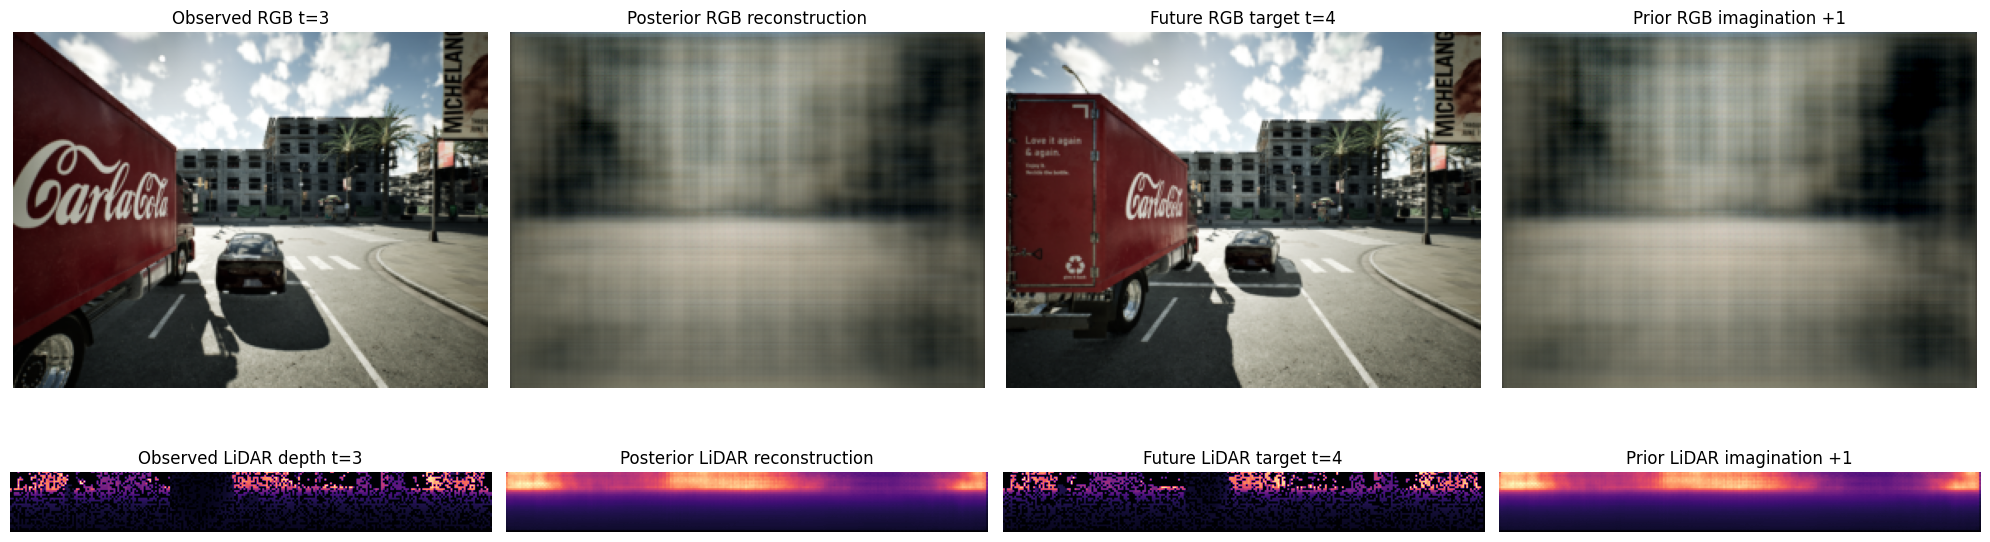

In [13]:
import glob
import matplotlib.pyplot as plt


def _latest_checkpoint(save_dir="./logs"):
    ckpts = glob.glob(os.path.join(save_dir, "**", "*.ckpt"), recursive=True)
    return max(ckpts, key=os.path.getmtime) if ckpts else None


def _to_rgb_image(tensor):
    return tensor.detach().float().cpu().permute(1, 2, 0).clamp(0, 1)


def _to_depth_image(tensor):
    return tensor.detach().float().cpu()


@torch.no_grad()
def visualize_reconstruction(sample_idx=0, obs_time_idx=-1, future_time_idx=0):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    if "train_ds" not in globals():
        arrow_file = "/home/carol/chaeyeon-kim/processed/train_run_002.arrow"
        globals()["train_ds"] = MUVODataset(
            arrow_file,
            seq_len=cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON,
            stride=cfg.RECEPTIVE_FIELD,
        )

    if "trained_model" not in globals():
        ckpt = _latest_checkpoint()
        if ckpt is None:
            raise RuntimeError("trained_model도 checkpoint도 없습니다. 먼저 학습 셀을 실행하세요.")
        globals()["trained_model"] = WorldModelTrainer.load_from_checkpoint(
            ckpt,
            cfg=cfg,
            lr=1e-4,
            embedding_n_channels=128,
        )
        print(f"Loaded checkpoint: {ckpt}")

    model = trained_model.to(device).eval()
    sample = train_ds[sample_idx]
    batch = {
        key: value.unsqueeze(0).to(device)
        for key, value in sample.items()
        if torch.is_tensor(value)
    }
    batch = model.prepare_custom_batch(batch)

    use_cuda_amp = device == "cuda"
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_cuda_amp):
        _, posterior_output, _, _, future_output = model._observe_and_imagine(batch)

    rf = cfg.RECEPTIVE_FIELD
    fh = cfg.FUTURE_HORIZON
    obs_t = obs_time_idx if obs_time_idx >= 0 else rf + obs_time_idx
    obs_t = max(0, min(obs_t, rf - 1))

    has_future = future_output is not None and fh > 0
    fut_t = max(0, min(future_time_idx, fh - 1)) if has_future else 0
    fut_batch_t = rf + fut_t

    input_rgb_obs = _to_rgb_image(batch["image_raw"][0, obs_t])
    pred_rgb_obs = _to_rgb_image(posterior_output["rgb_2"][0, obs_t])
    input_depth_obs = _to_depth_image(batch["lidar"][0, obs_t, 3])
    pred_depth_obs = _to_depth_image(posterior_output["lidar_reconstruction_2"][0, obs_t, 3])

    fig, axes = plt.subplots(2, 4 if has_future else 2, figsize=(20 if has_future else 10, 7))
    axes = np.asarray(axes)

    axes[0, 0].imshow(input_rgb_obs)
    axes[0, 0].set_title(f"Observed RGB t={obs_t}")
    axes[0, 1].imshow(pred_rgb_obs)
    axes[0, 1].set_title("Posterior RGB reconstruction")
    axes[1, 0].imshow(input_depth_obs, cmap="magma")
    axes[1, 0].set_title(f"Observed LiDAR depth t={obs_t}")
    axes[1, 1].imshow(pred_depth_obs, cmap="magma")
    axes[1, 1].set_title("Posterior LiDAR reconstruction")

    if has_future:
        target_rgb_future = _to_rgb_image(batch["image_raw"][0, fut_batch_t])
        pred_rgb_future = _to_rgb_image(future_output["rgb_2"][0, fut_t])
        target_depth_future = _to_depth_image(batch["lidar"][0, fut_batch_t, 3])
        pred_depth_future = _to_depth_image(future_output["lidar_reconstruction_2"][0, fut_t, 3])

        axes[0, 2].imshow(target_rgb_future)
        axes[0, 2].set_title(f"Future RGB target t={fut_batch_t}")
        axes[0, 3].imshow(pred_rgb_future)
        axes[0, 3].set_title(f"Prior RGB imagination +{fut_t + 1}")
        axes[1, 2].imshow(target_depth_future, cmap="magma")
        axes[1, 2].set_title(f"Future LiDAR target t={fut_batch_t}")
        axes[1, 3].imshow(pred_depth_future, cmap="magma")
        axes[1, 3].set_title(f"Prior LiDAR imagination +{fut_t + 1}")

    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# 학습 후 필요할 때 수동 실행하세요.
visualize_reconstruction(sample_idx=0, obs_time_idx=-1, future_time_idx=0)


Loaded TensorBoard scalars from: ./logs/lightning_logs/version_10/events.out.tfevents.1777695076.DESKTOP-0DP4OD6.138601.0


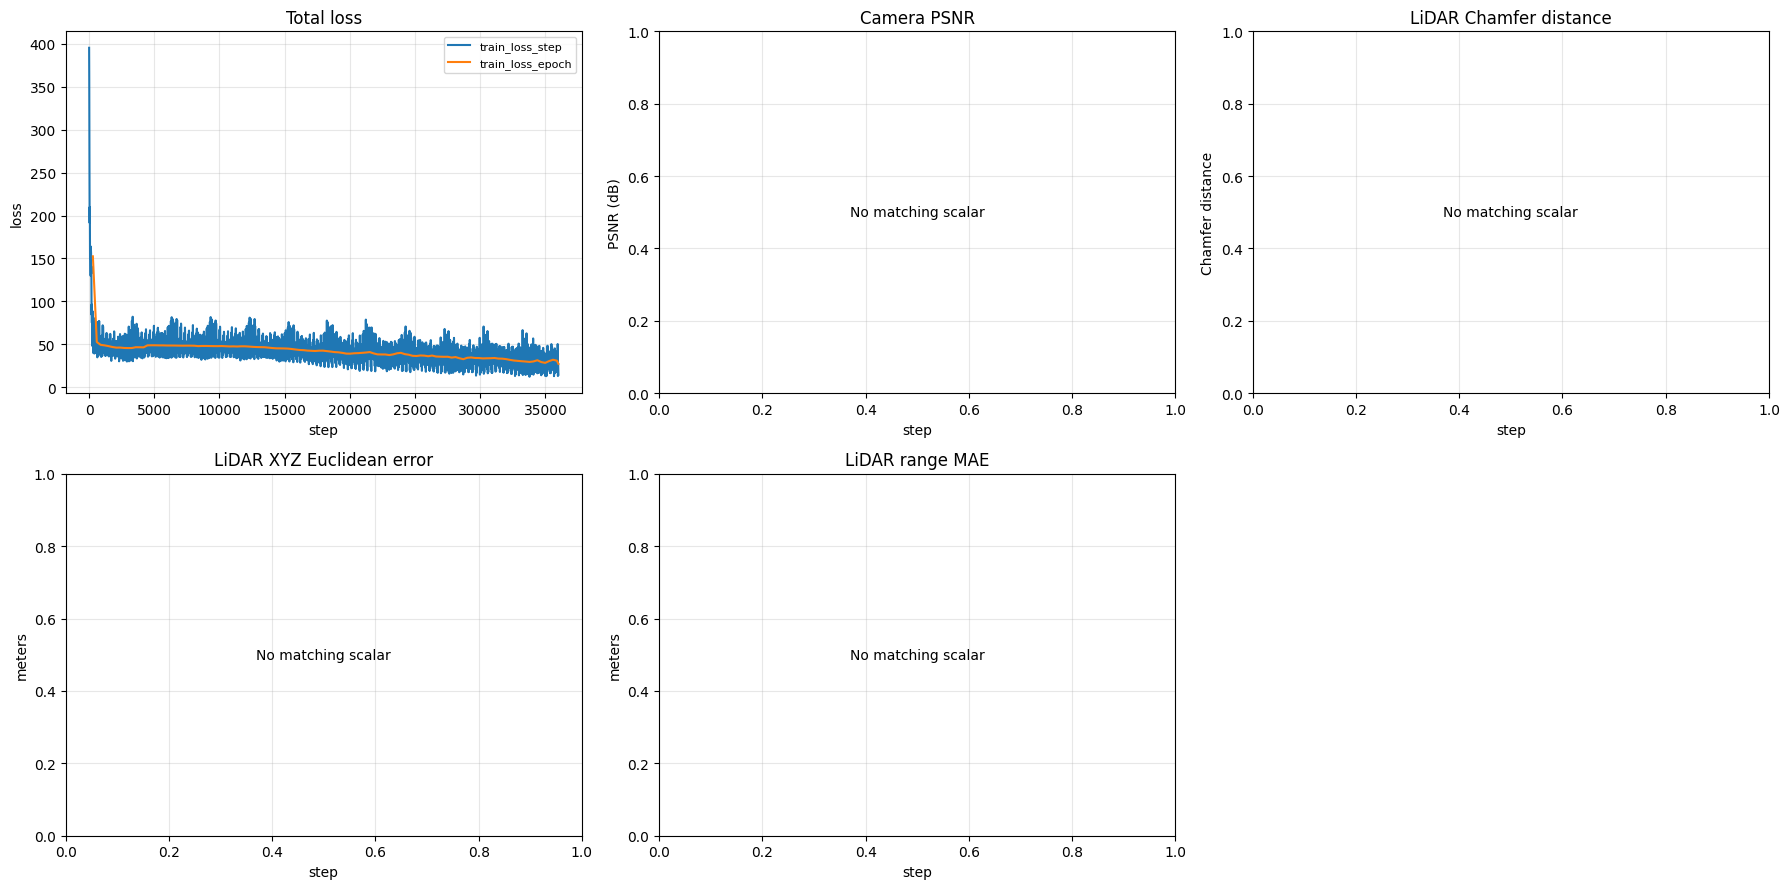

In [14]:
#######################
# Loss / metric plots from TensorBoard logs
#######################
import glob
import os
import matplotlib.pyplot as plt

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except ImportError as exc:
    raise ImportError("TensorBoard가 필요합니다. 현재 학습 환경에서 `pip install tensorboard` 후 다시 실행하세요.") from exc


def _latest_event_file(log_root="./logs/lightning_logs"):
    event_files = glob.glob(os.path.join(log_root, "**", "events.out.tfevents.*"), recursive=True)
    if not event_files:
        raise FileNotFoundError(f"TensorBoard event file을 찾지 못했습니다: {log_root}")
    return max(event_files, key=os.path.getmtime)


def load_tensorboard_scalars(event_file=None, log_root="./logs/lightning_logs"):
    event_file = event_file or _latest_event_file(log_root)
    accumulator = EventAccumulator(event_file)
    accumulator.Reload()
    scalars = {}
    for tag in accumulator.Tags().get("scalars", []):
        events = accumulator.Scalars(tag)
        scalars[tag] = {
            "step": [event.step for event in events],
            "value": [event.value for event in events],
        }
    print(f"Loaded TensorBoard scalars from: {event_file}")
    return scalars


def _plot_tags(ax, scalars, tags, title, ylabel):
    found = False
    for tag in tags:
        if tag in scalars:
            ax.plot(scalars[tag]["step"], scalars[tag]["value"], label=tag)
            found = True
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if found:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No matching scalar", ha="center", va="center", transform=ax.transAxes)


def plot_loss_and_eval_metrics(log_root="./logs/lightning_logs"):
    scalars = load_tensorboard_scalars(log_root=log_root)
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    _plot_tags(
        axes[0, 0], scalars,
        ["train_loss_step", "train_loss_epoch", "val/RL_loss", "val/DS_loss"],
        "Total loss", "loss",
    )
    _plot_tags(
        axes[0, 1], scalars,
        ["val/RL_rgb_psnr", "val/DS_rgb_psnr", "val/RL_future_rgb_psnr", "val/DS_future_rgb_psnr"],
        "Camera PSNR", "PSNR (dB)",
    )
    _plot_tags(
        axes[0, 2], scalars,
        ["val/RL_lidar_chamfer_xyz", "val/DS_lidar_chamfer_xyz", "val/RL_future_lidar_chamfer_xyz", "val/DS_future_lidar_chamfer_xyz"],
        "LiDAR Chamfer distance", "Chamfer distance",
    )
    _plot_tags(
        axes[1, 0], scalars,
        ["val/RL_lidar_xyz_euclidean", "val/DS_lidar_xyz_euclidean", "val/RL_future_lidar_xyz_euclidean", "val/DS_future_lidar_xyz_euclidean"],
        "LiDAR XYZ Euclidean error", "meters",
    )
    _plot_tags(
        axes[1, 1], scalars,
        ["val/RL_lidar_range_mae", "val/DS_lidar_range_mae", "val/RL_future_lidar_range_mae", "val/DS_future_lidar_range_mae"],
        "LiDAR range MAE", "meters",
    )
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()
    return scalars


# 학습 후 실행하면 Fig. 스타일의 loss/PSNR/Chamfer 그래프를 확인할 수 있습니다.
scalars = plot_loss_and_eval_metrics()
